# Warsaw PM2.5 — Exploratory Data Analysis

## Executive Summary
**Objective:** Characterise the Warsaw PM2.5 dataset (2019–2024, 7 stations, hourly) to guide feature engineering and model selection.

**Key Findings:**
- Strong winter seasonality: PM2.5 peaks Dec–Feb due to domestic heating and stable anticyclonic weather.
- Boundary Layer Height (`blh`) is the single most important physical predictor — when BLH collapses to <200 m, PM2.5 spikes regardless of emissions.
- HYSPLIT back-trajectories from the S/SW (continental air masses carrying industrial + coal emissions) are associated with the highest concentrations.
- +24h persistence baseline achieves R²≈0.10 — weather-driven methods are necessary for day-ahead forecasting.

**Conclusions:** Feature engineering should emphasise BLH, seasonal cycling, PM2.5 autoregression (lag 24h), and HYSPLIT trajectory features.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from src.config import (
    DATA_PATH, TARGET, NEIGHBOR_STATIONS, MET_COLS, HYSPLIT_NUMERIC,
    WHO_24H_PM25, ALERT_THRESHOLD, FIGURES_DIR, RESULTS_DIR, STATION_COORDS
)
from src.data_loader import load_data, train_test_split
from src.evaluation import compute_metrics
from src.utils import ensure_dirs

ensure_dirs(FIGURES_DIR, RESULTS_DIR)
sns.set_theme(style='whitegrid', palette='tab10')
print('Setup complete')

Setup complete


## 1. Data Overview
Load the merged CSV, inspect shape, dtypes, date range, and visualise missing values.

In [2]:
df = load_data(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Date range: {df.index.min()} → {df.index.max()}')
print(f'\nColumn dtypes:\n{df.dtypes.value_counts()}')
df.describe().round(2)

12:47:28 | src.data_loader | INFO | Loading data from D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\data\raw\FINAL_merged_PM25_1g_all_seasons.csv
12:47:28 | src.data_loader | INFO | Missing values per column:
MzOtwoBrzozo    1084
MzWarWokalna    2028
MzWarAlNiepo     575
MzLegZegrzyn    1511
MzPiasPulask    1002
MzWarChrosci     416
MzWarBajkowa     636
dir_48            48
dir_24            48
12:47:28 | src.data_loader | INFO | Loaded 52608 rows, 27 columns, range 2019-01-01 00:00:00 → 2024-12-31 23:00:00


Shape: (52608, 27)
Date range: 2019-01-01 00:00:00 → 2024-12-31 23:00:00

Column dtypes:
float64    23
int64       2
object      2
Name: count, dtype: int64


,TEMP,WIND_SPEED,PRESS_SEA,HUMIDITY,DEW_POINT,RAIN_6H,SUNSHINE,MzOtwoBrzozo,MzWarWokalna,MzWarAlNiepo,...,lon_48,lat_48,dist_48_straight,dist_48_total,ratio_48,lon_24,lat_24,dist_24_straight,dist_24_total,ratio_24
count,52608.00,52608.00,52608.00,52608.00,52608.00,52608.00,52608.00,51524.00,50580.00,52033.00,...,52608.00,52608.00,52608.00,52608.00,52608.00,52608.00,52608.00,52608.00,52608.00,52608.00
mean,10.48,3.29,1015.88,73.72,5.32,0.06,0.15,19.74,14.24,18.73,...,12.09,53.44,1223.14,1443.78,0.82,16.63,52.37,659.72,712.27,0.90
std,8.68,1.87,9.09,18.88,7.08,0.71,0.33,19.96,10.86,12.06,...,15.30,6.90,686.40,653.21,0.19,8.09,3.84,361.52,349.80,0.15
min,-20.20,0.00,977.10,15.00,-22.30,0.00,0.00,0.04,0.09,0.41,...,-40.46,27.24,7.06,274.41,0.01,-6.53,36.74,20.24,84.36,0.06
25%,3.50,2.00,1010.40,60.00,0.10,0.00,0.00,8.00,6.40,10.40,...,1.49,48.53,703.66,937.09,0.75,10.79,49.78,395.58,454.16,0.88
50%,9.80,3.00,1016.00,78.00,5.20,0.00,0.00,13.90,11.50,15.50,...,12.62,52.85,1108.35,1343.26,0.89,17.42,52.24,597.22,651.80,0.96
75%,17.30,4.00,1021.70,90.00,11.00,0.00,0.00,24.10,19.07,23.64,...,23.16,57.42,1647.12,1820.28,0.96,22.21,54.88,870.14,912.59,0.98
max,35.20,15.00,1047.40,100.00,22.80,60.20,1.00,312.92,132.06,149.80,...,53.22,79.97,3994.79,4095.08,1.00,41.54,69.75,1958.17,2020.63,1.00


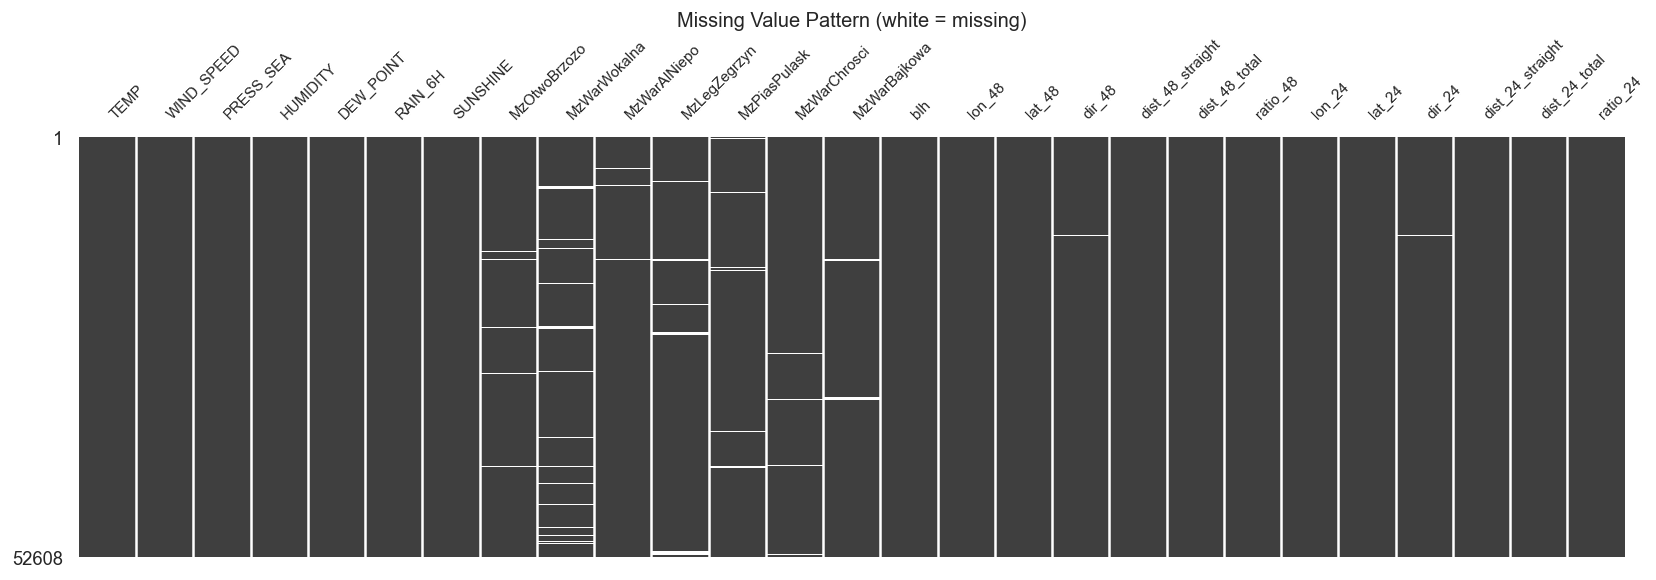

In [3]:
import missingno as msno

fig, ax = plt.subplots(figsize=(14, 5))
msno.matrix(df, ax=ax, sparkline=False, fontsize=9)
ax.set_title('Missing Value Pattern (white = missing)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'missing_values.png', bbox_inches='tight')
plt.show()

## 2. Target Distribution
PM2.5 is right-skewed — a log transform is warranted for all regression models.

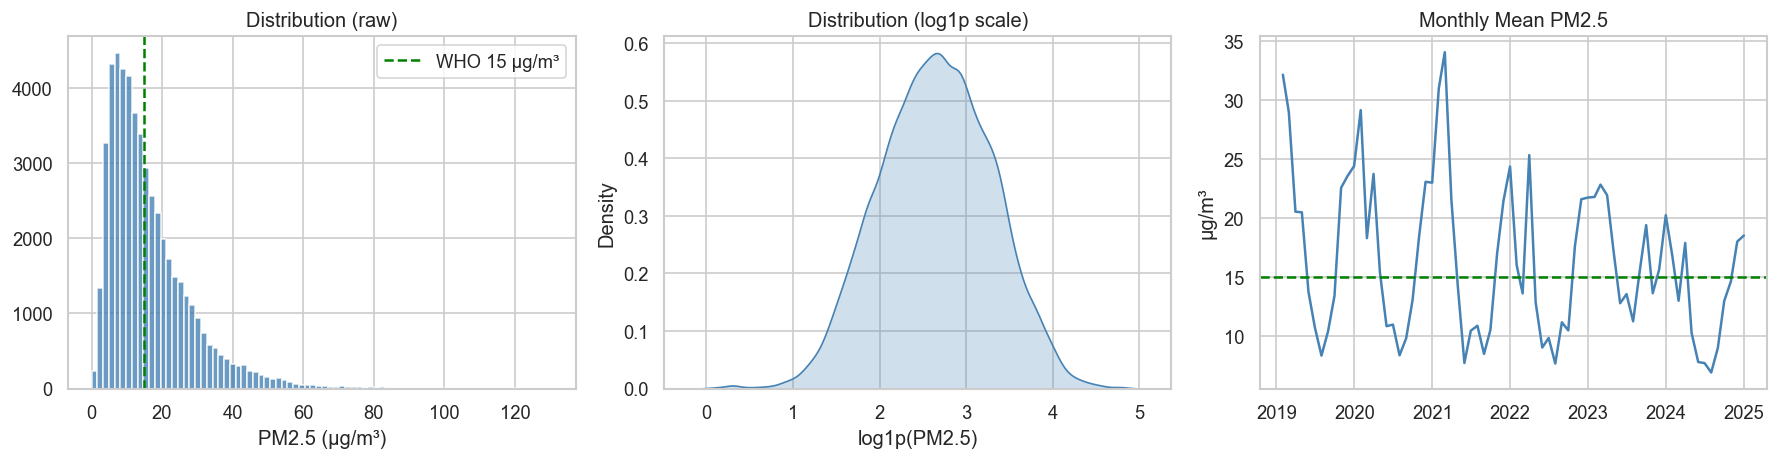

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Raw histogram
axes[0].hist(df[TARGET].dropna(), bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(WHO_24H_PM25, color='green', linestyle='--', label=f'WHO {WHO_24H_PM25} µg/m³')
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].set_title('Distribution (raw)')
axes[0].legend()

# Log-scale KDE
sns.kdeplot(np.log1p(df[TARGET].dropna()), ax=axes[1], fill=True, color='steelblue')
axes[1].set_xlabel('log1p(PM2.5)')
axes[1].set_title('Distribution (log1p scale)')

# Monthly mean
monthly = df[TARGET].resample('ME').mean()
axes[2].plot(monthly.index, monthly.values, color='steelblue', linewidth=1.5)
axes[2].axhline(WHO_24H_PM25, color='green', linestyle='--')
axes[2].set_title('Monthly Mean PM2.5')
axes[2].set_ylabel('µg/m³')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'target_distribution.png', bbox_inches='tight')
plt.show()

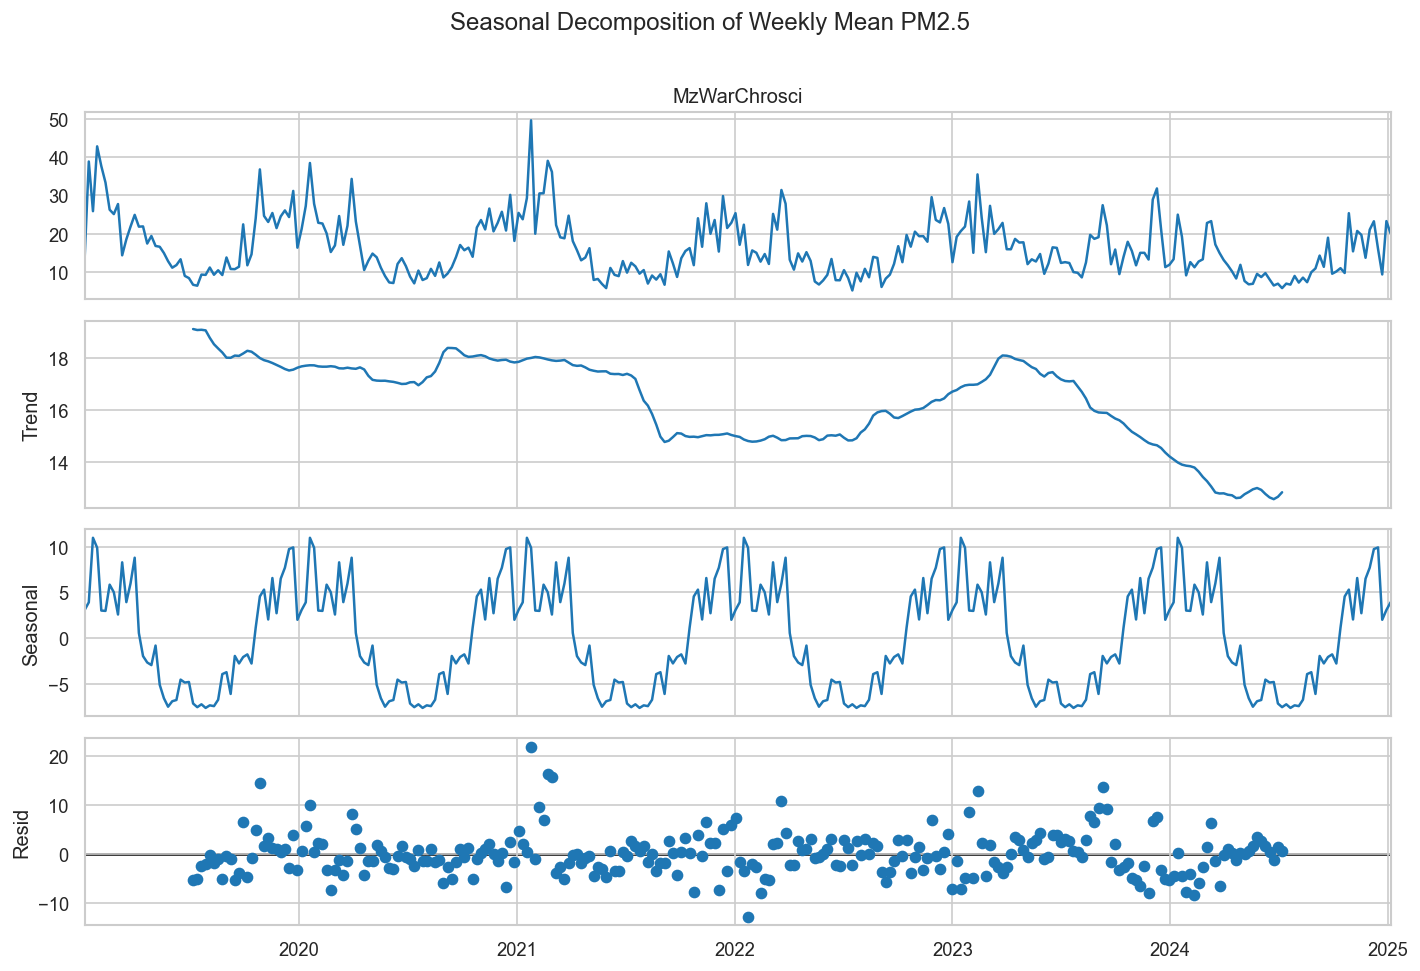

In [5]:
# Seasonal decomposition on weekly-resampled series (cleaner visualisation)
weekly = df[TARGET].resample('W').mean().dropna()
decomp = seasonal_decompose(weekly, model='additive', period=52)
fig = decomp.plot()
fig.set_size_inches(12, 8)
fig.suptitle('Seasonal Decomposition of Weekly Mean PM2.5', y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'seasonal_decomposition.png', bbox_inches='tight')
plt.show()

## 3. Temporal Patterns
Diurnal and seasonal patterns reveal emission sources: rush-hour peaks, heating season dominance.

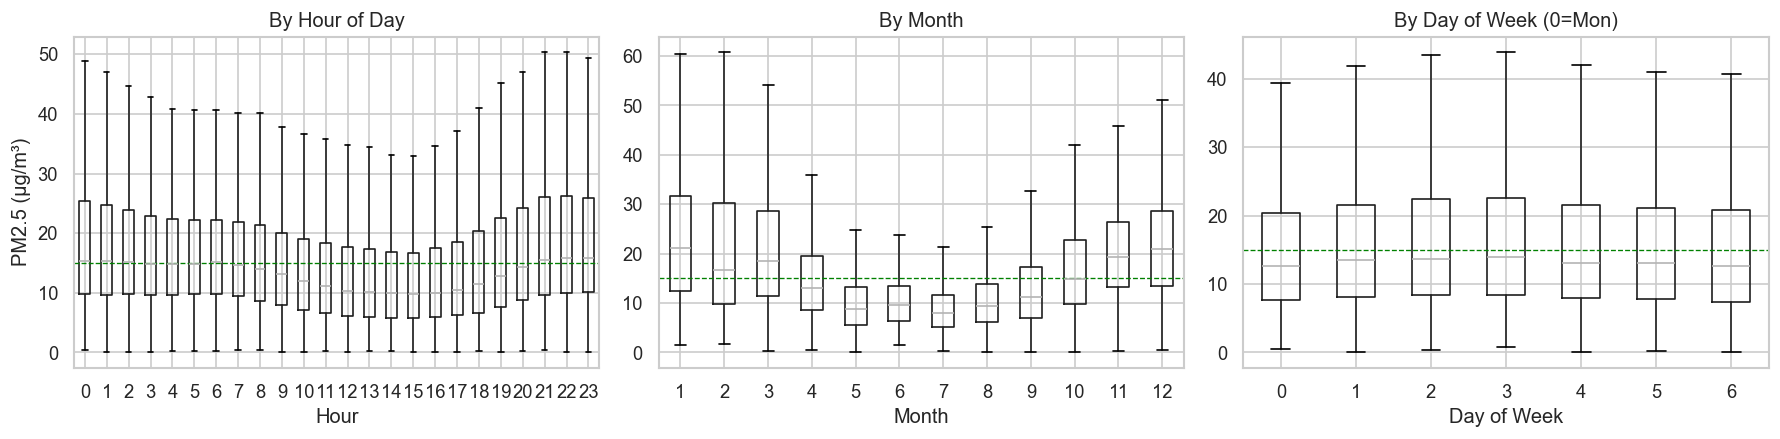

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

temp_df = df[[TARGET]].copy()
temp_df['hour'] = temp_df.index.hour
temp_df['month'] = temp_df.index.month
temp_df['dow'] = temp_df.index.day_of_week

temp_df.boxplot(column=TARGET, by='hour', ax=axes[0], showfliers=False)
axes[0].set_title('By Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('PM2.5 (µg/m³)')

temp_df.boxplot(column=TARGET, by='month', ax=axes[1], showfliers=False)
axes[1].set_title('By Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('')

temp_df.boxplot(column=TARGET, by='dow', ax=axes[2], showfliers=False)
axes[2].set_title('By Day of Week (0=Mon)')
axes[2].set_xlabel('Day of Week')
axes[2].set_ylabel('')

for ax in axes:
    ax.axhline(WHO_24H_PM25, color='green', linestyle='--', linewidth=0.8)

fig.suptitle('')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'temporal_patterns.png', bbox_inches='tight')
plt.show()

## 4. Correlation Analysis

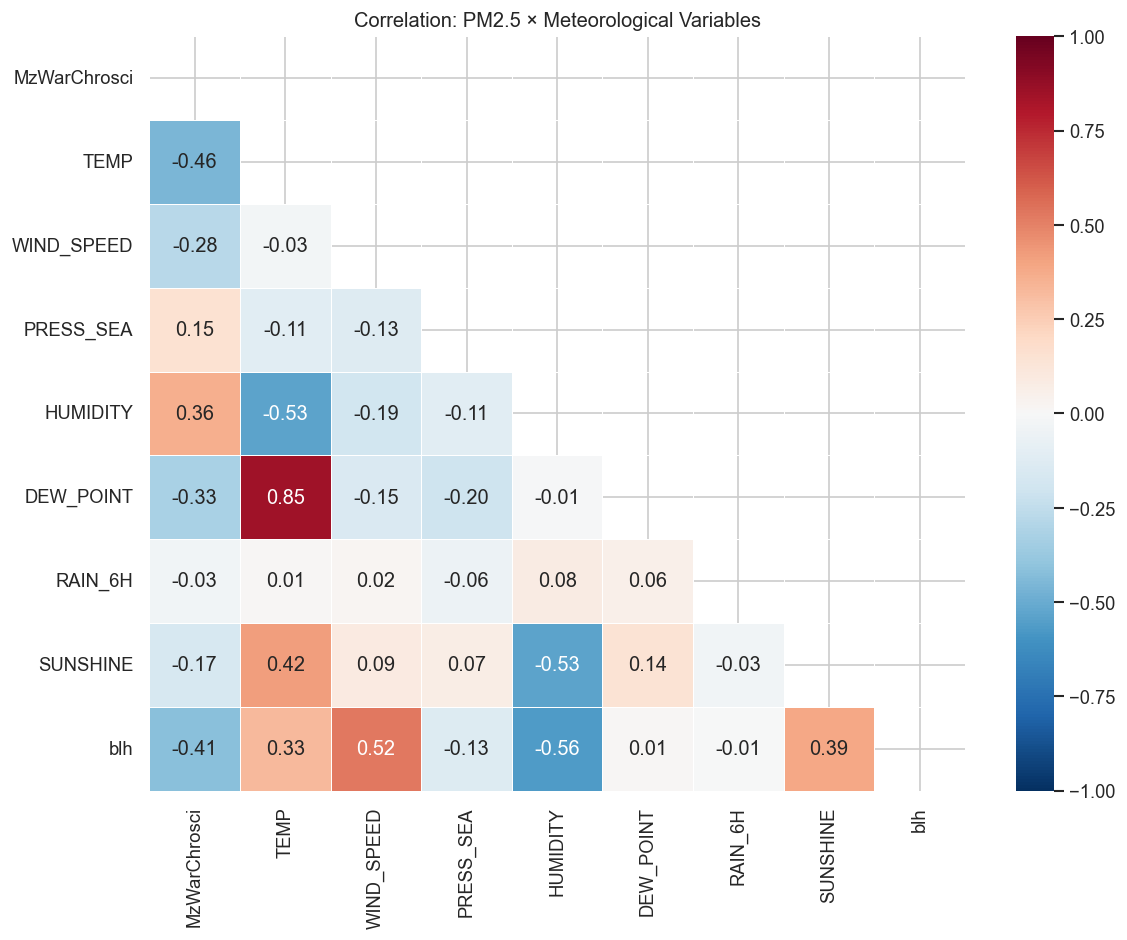

In [7]:
corr_cols = [TARGET] + MET_COLS
corr_cols = [c for c in corr_cols if c in df.columns]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlation: PM2.5 × Meteorological Variables')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 5. Boundary Layer Height Analysis
BLH is the dominant physical control: low BLH → concentrated pollution. This is the "smog lid" effect.

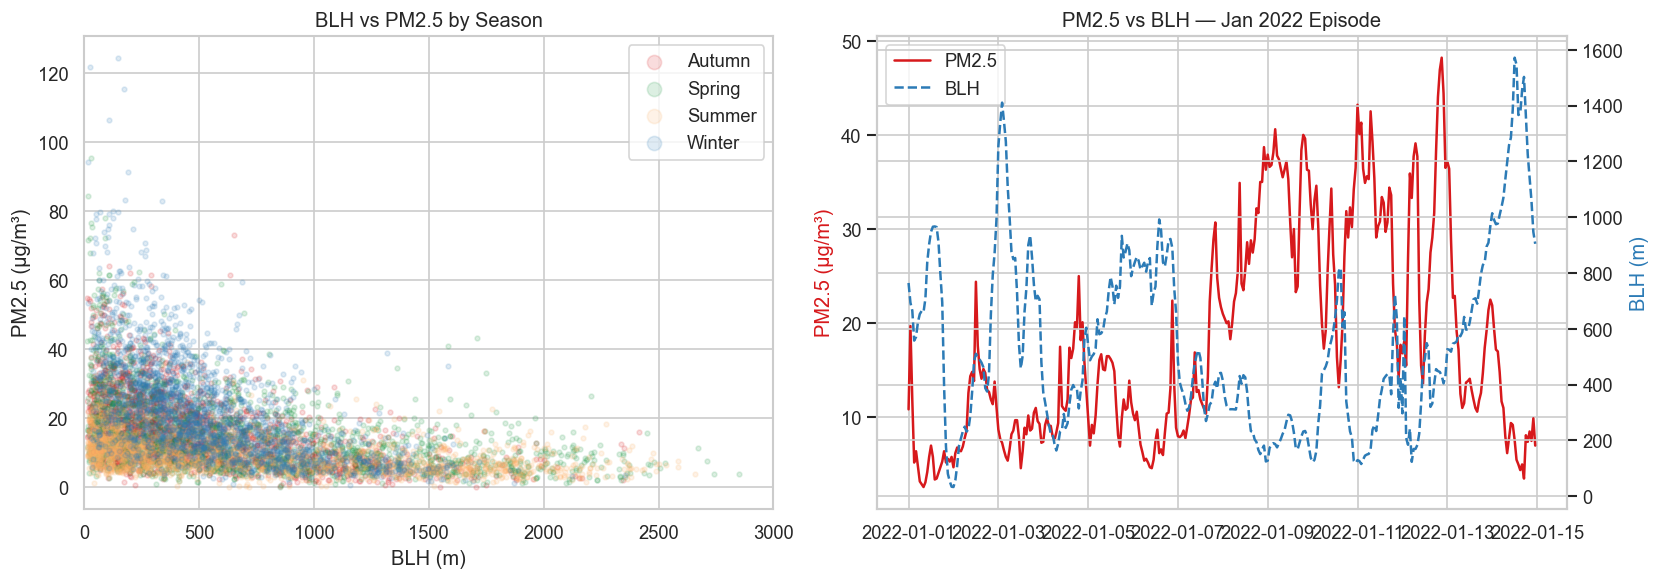

In [8]:
seasons = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Autumn'}
df_blh = df[[TARGET, 'blh']].dropna().copy()
df_blh['season'] = pd.cut(df_blh.index.month,
                           bins=[0, 2, 5, 8, 11, 12],
                           labels=['Winter','Spring','Summer','Autumn','Winter2'])
# Simplify
df_blh['season'] = df_blh.index.month.map(
    lambda m: 'Winter' if m in [12,1,2] else
              'Spring' if m in [3,4,5] else
              'Summer' if m in [6,7,8] else 'Autumn'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = {'Winter': '#2c7bb6', 'Spring': '#1a9641', 'Summer': '#fdae61', 'Autumn': '#d7191c'}

for season, grp in df_blh.groupby('season'):
    sample = grp.sample(min(2000, len(grp)), random_state=42)
    axes[0].scatter(sample['blh'], sample[TARGET], alpha=0.15, s=8,
                    color=palette.get(season, 'grey'), label=season)
axes[0].set_xlabel('BLH (m)')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].set_title('BLH vs PM2.5 by Season')
axes[0].legend(markerscale=3)
axes[0].set_xlim(0, 3000)

# BLH during a smog episode (Jan 2022 example)
ep = df.loc['2022-01-01':'2022-01-14', [TARGET, 'blh']].dropna()
ax2 = axes[1]
ax2b = ax2.twinx()
ax2.plot(ep.index, ep[TARGET], color='#d7191c', label='PM2.5', linewidth=1.5)
ax2b.plot(ep.index, ep['blh'], color='#2c7bb6', label='BLH', linewidth=1.5, linestyle='--')
ax2.set_ylabel('PM2.5 (µg/m³)', color='#d7191c')
ax2b.set_ylabel('BLH (m)', color='#2c7bb6')
ax2.set_title('PM2.5 vs BLH — Jan 2022 Episode')
lines1, labs1 = ax2.get_legend_handles_labels()
lines2, labs2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labs1 + labs2)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'blh_analysis.png', bbox_inches='tight')
plt.show()

## 6. HYSPLIT Trajectory Analysis
Air mass origin (back-trajectory direction) strongly predicts PM2.5 levels.

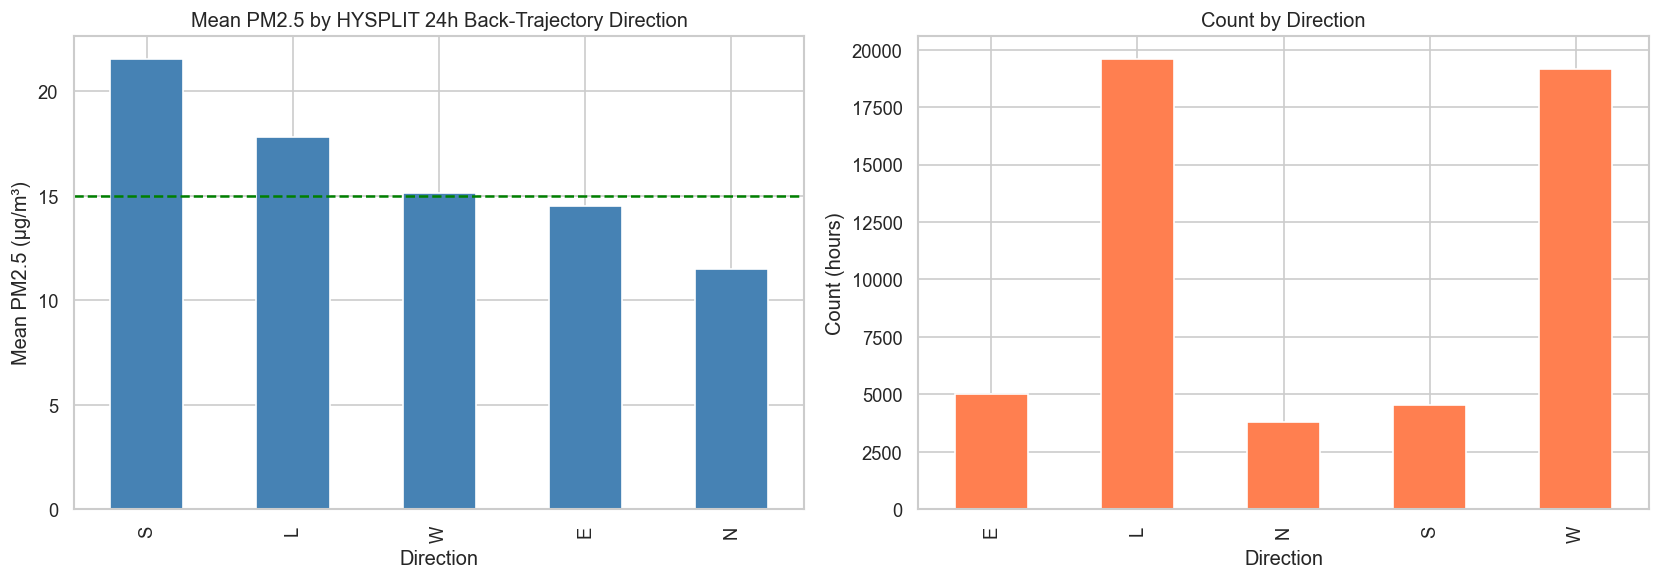

In [9]:
if 'dir_24' in df.columns:
    dir_pm25 = df[[TARGET, 'dir_24']].dropna()
    dir_means = dir_pm25.groupby('dir_24')[TARGET].mean().sort_values(ascending=False)
    dir_counts = dir_pm25.groupby('dir_24')[TARGET].count()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    dir_means.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].axhline(WHO_24H_PM25, color='green', linestyle='--')
    axes[0].set_title('Mean PM2.5 by HYSPLIT 24h Back-Trajectory Direction')
    axes[0].set_ylabel('Mean PM2.5 (µg/m³)')
    axes[0].set_xlabel('Direction')

    dir_counts.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
    axes[1].set_title('Count by Direction')
    axes[1].set_ylabel('Count (hours)')
    axes[1].set_xlabel('Direction')

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'hysplit_analysis.png', bbox_inches='tight')
    plt.show()
else:
    print('dir_24 column not found — skipping HYSPLIT direction analysis')

## 7. Station Spatial Map
Visualise the 7 monitoring stations on an interactive Folium map and show inter-station PM2.5 correlations.

In [10]:
try:
    import folium
    from IPython.display import display

    target_lat, target_lon = STATION_COORDS[TARGET]
    m = folium.Map(location=[target_lat, target_lon], zoom_start=10)

    for station, (lat, lon) in STATION_COORDS.items():
        color = 'red' if station == TARGET else 'blue'
        mean_pm25 = df[station].mean() if station in df.columns else None
        popup_text = f'{station}<br>Mean PM2.5: {mean_pm25:.1f} µg/m³' if mean_pm25 else station
        folium.CircleMarker(
            location=[lat, lon], radius=8, color=color, fill=True, fill_opacity=0.7,
            popup=folium.Popup(popup_text, max_width=200)
        ).add_to(m)

    map_path = FIGURES_DIR / 'station_map.html'
    m.save(str(map_path))
    print(f'Interactive map saved to {map_path}')
    display(m)
except ImportError:
    print('folium not installed — skipping map')

Interactive map saved to D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\figures\station_map.html


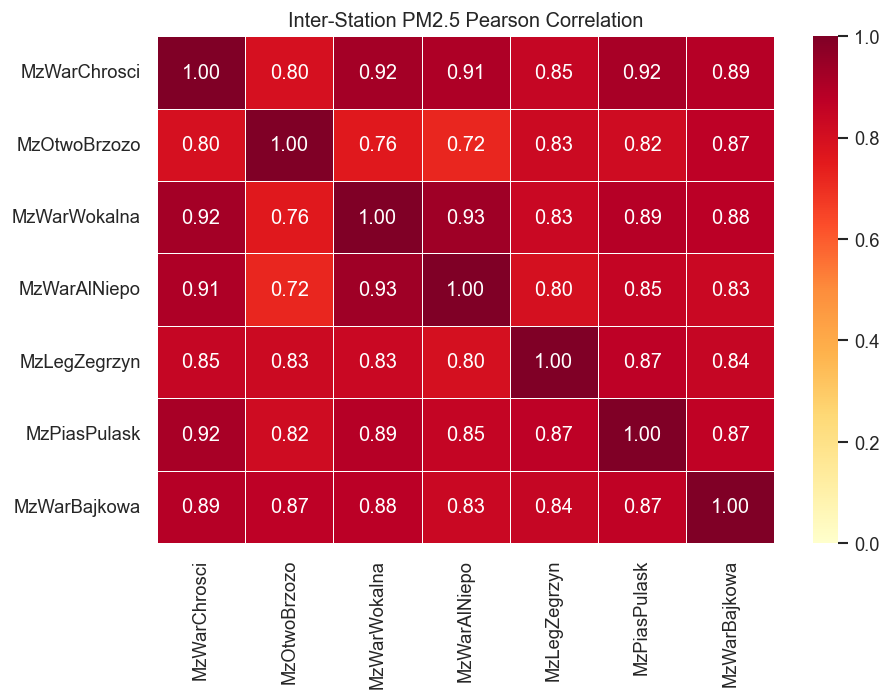

In [11]:
# Inter-station PM2.5 correlation matrix
all_stations = [TARGET] + NEIGHBOR_STATIONS
present = [s for s in all_stations if s in df.columns]
station_corr = df[present].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(station_corr, annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Inter-Station PM2.5 Pearson Correlation')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'station_correlation.png', bbox_inches='tight')
plt.show()

## 8. Stationarity Tests
ADF test and ACF/PACF to understand autocorrelation structure for lag selection.

In [12]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

series = df[TARGET].dropna()
adf_result = adfuller(series, autolag='AIC')
print('ADF Test Results:')
print(f'  Statistic : {adf_result[0]:.4f}')
print(f'  p-value   : {adf_result[1]:.6f}')
print(f'  Lags used : {adf_result[2]}')
print(f'  Conclusion: {"Stationary" if adf_result[1] < 0.05 else "Non-stationary"} (α=0.05)')

ADF Test Results:
  Statistic : -16.4690
  p-value   : 0.000000
  Lags used : 58
  Conclusion: Stationary (α=0.05)


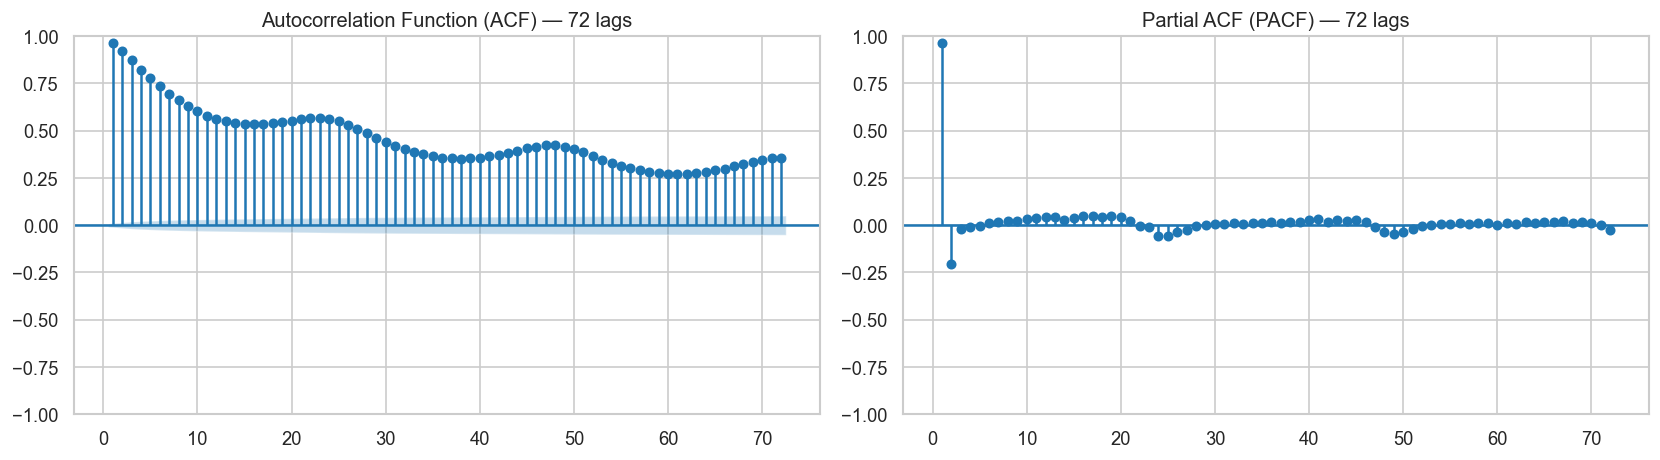

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series, lags=72, ax=axes[0], zero=False)
axes[0].set_title('Autocorrelation Function (ACF) — 72 lags')
plot_pacf(series, lags=72, ax=axes[1], zero=False, method='ywm')
axes[1].set_title('Partial ACF (PACF) — 72 lags')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'acf_pacf.png', bbox_inches='tight')
plt.show()

## 9. Naive Baseline: +24h Persistence
"Tomorrow equals today" — the floor all models must beat.

In [14]:
train_df, test_df = train_test_split(df)

y_true_naive = test_df[TARGET].dropna()
# Persistence: predict t+24 using the value at t (i.e. lag 24h of the TEST series)
y_naive_pred = test_df[TARGET].shift(24).reindex(y_true_naive.index)
valid_mask = y_naive_pred.notna()

baseline_metrics = compute_metrics(y_true_naive[valid_mask].values, y_naive_pred[valid_mask].values)
print('Naive +24h Persistence Baseline (2024 test set):')
for k, v in baseline_metrics.items():
    print(f'  {k}: {v}')

# Save to results
pd.DataFrame([{**{"Model": "Naive_persistence_24h", "Horizon": 24}, **baseline_metrics}]).to_csv(
    RESULTS_DIR / 'naive_baseline.csv', index=False
)
print('\nNaive baseline saved to outputs/results/naive_baseline.csv')

12:47:55 | src.data_loader | INFO | Train: 43824 rows (2019-01-01 00:00:00 → 2023-12-31 23:00:00)
12:47:55 | src.data_loader | INFO | Test : 8784 rows (2024-01-01 00:00:00 → 2024-12-31 23:00:00)


Naive +24h Persistence Baseline (2024 test set):
  MAE: 5.4124
  RMSE: 7.9468
  R2: 0.0987
  MBE: 0.0172
  IA: 0.7338

Naive baseline saved to outputs/results/naive_baseline.csv
